
# Hybrid ray + wave optics demo: rotating phase screen -> DM -> Shack–Hartmann WFS

This notebook is a compact end-to-end sanity check for the current `optics_simulator` architecture.

It demonstrates:

1. A collimated beam propagating geometrically through an `OpticalBench3D`.
2. A rotating phase screen contributing OPD.
3. A deformable mirror contributing an OPD correction.
4. A Shack–Hartmann WFS plane represented by a lenslet-array geometry object.
5. Wave-optics handoff at the SH plane, slicing the pupil field into lenslets and propagating each lenslet to a focal spot.

The propagation philosophy is deliberately hybrid:

\[
\text{ray geometry / OPD sampling up to SH plane}
\quad \rightarrow \quad
\text{Wavefront2D at SH plane}
\quad \rightarrow \quad
\text{per-lenslet Fresnel / focal-plane propagation}
\]

This is *not* yet a full multi-plane Fresnel propagation through every upstream element; it is a practical Shack–Hartmann simulation layer built on top of the geometric bench.


In [ ]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()

candidate_roots = [
    cwd,
    cwd.parent,
    cwd.parent.parent,
]

for root in candidate_roots:
    if (root / "optics_simulator").exists():
        REPO_ROOT = root
        break
else:
    raise RuntimeError(
        "Could not find repository root containing optics_simulator/"
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repository root:", REPO_ROOT)

from optics_simulator import beam_trace as bt
from optics_simulator import beam_trace_wave as btw
from optics_simulator import fresnel
from optics_simulator import phase_tools
from optics_simulator import wave_optics
from optics_simulator import psf_tools
from optics_simulator.wavefront import Wavefront2D

print("beam_trace:", bt.__file__)

required = [
    "RotatingPhaseScreen3D",
    "DeformableMirror3D",
    "ShackHartmannWFS3D",
    "OpticalBench3D",
    "Beam3D",
]

for name in required:
    print(f"{name:24s}", hasattr(bt, name))

missing = [name for name in required if not hasattr(bt, name)]
if missing:
    raise RuntimeError(
        "Your beam_trace.py does not yet expose the required class(es): "
        + ", ".join(missing)
    )

Repository root: /home/bbarrer/Documents/ULTIMATE/repositories/mq_glao_testbench_sim
beam_trace: /home/bbarrer/Documents/ULTIMATE/repositories/mq_glao_testbench_sim/optics_simulator/beam_trace.py
RotatingPhaseScreen3D    True
DeformableMirror3D       True
ShackHartmannWFS3D       True
OpticalBench3D           True
Beam3D                   True



## Configuration

The numbers below are intentionally small/simple so the notebook runs quickly. They are not meant to represent an optimised physical design.

A few conventions:

- `beam_diameter` is the clear beam diameter sampled by the geometric model.
- `gaussian_waist_factor = 1` means the Gaussian field amplitude is \(1/e\) at the nominal beam radius, so intensity is \(1/e^2\) there.
- The DM commands are chosen by sampling the phase-screen OPD at the actuator centres and applying a partial opposite command. This is a simple demonstration correction, not a proper reconstructor.


In [2]:

# Global parameters

wavelength = 633e-9
beam_diameter = 6.0e-3
beam_radius = 0.5 * beam_diameter

npix_pupil = 192
t_demo = 0.30

screen_z = 0.0
dm_z = 0.10
sh_z = 0.22

screen_extent = 18e-3
screen_clear_radius = 8e-3

dm_nact = 10
dm_pitch = beam_diameter / dm_nact
dm_opd_per_command = 500e-9
dm_coupling = 0.35
dm_correction_gain = 0.65

sh_n_lenslets = (8, 8)
sh_pitch = beam_diameter / sh_n_lenslets[1]
sh_diameter = 0.90 * sh_pitch
sh_focal_length = 25e-3
sh_pixels_per_lenslet = 32
sh_fft_pad = 128

use_gaussian_beam = True
gaussian_waist_factor = 1.0
gaussian_waist_radius = gaussian_waist_factor * beam_radius

print("beam diameter [mm]:", beam_diameter * 1e3)
print("DM pitch [mm]:", dm_pitch * 1e3)
print("SH pitch [mm]:", sh_pitch * 1e3)
print("SH lenslet diameter [mm]:", sh_diameter * 1e3)
print("Gaussian waist radius [mm]:", gaussian_waist_radius * 1e3)


beam diameter [mm]: 6.0
DM pitch [mm]: 0.6000000000000001
SH pitch [mm]: 0.75
SH lenslet diameter [mm]: 0.675
Gaussian waist radius [mm]: 3.0


In [7]:
# Helper functions

# Deliberately avoid wavefront_from_amplitude_phase() here.  Some local versions
# of that helper have returned None during refactors.  The GLAO scripts work
# because they use beam_trace_wave.sample_wavefront_and_beam_sample_on_pupil_plane,
# so we use that path first and only fall back to direct Wavefront2D construction.


def make_demo_opd_map(n=512, extent_m=18e-3, rms_opd_m=180e-9, seed=2):
    """
    Make a deterministic, smooth OPD map for the rotating phase screen.
    """
    rng = np.random.default_rng(seed)
    x = np.linspace(-extent_m / 2, extent_m / 2, n)
    y = np.linspace(-extent_m / 2, extent_m / 2, n)
    xx, yy = np.meshgrid(x, y)

    opd = (
        0.8 * np.sin(2 * np.pi * xx / 8.0e-3)
        + 0.5 * np.cos(2 * np.pi * yy / 6.0e-3)
        + 0.7 * ((xx / (0.5 * extent_m)) ** 2 - (yy / (0.5 * extent_m)) ** 2)
    )

    try:
        from scipy.ndimage import gaussian_filter
        rand = gaussian_filter(rng.normal(size=(n, n)), sigma=18)
        rand = rand / np.std(rand)
        opd = opd + 0.25 * rand
    except Exception:
        pass

    opd -= np.mean(opd)
    opd *= rms_opd_m / np.std(opd)

    return opd


def apply_gaussian_amplitude_local(
    wf,
    waist_radius_m,
    center_m=(0.0, 0.0),
    truncate=True,
    label=None,
):
    """
    Apply a Gaussian field-amplitude envelope.

    waist_radius_m is the 1/e field-amplitude radius, equivalently the
    1/e^2 intensity radius.

    This helper is deliberately self-contained for the notebook. It does not
    rely on wave_optics.apply_gaussian_amplitude(), because some local versions
    may exist but return None during refactoring.
    """
    if wf is None:
        raise RuntimeError("apply_gaussian_amplitude_local received wf=None.")

    x0, y0 = center_m

    r2 = (wf.x - x0) ** 2 + (wf.y - y0) ** 2
    amp = np.exp(-r2 / float(waist_radius_m) ** 2)

    if truncate:
        amp = amp * (wf.amplitude > 0)

    new_field = wf.field * amp

    return Wavefront2D(
        field=new_field,
        wavelength=wf.wavelength,
        dx=wf.dx,
        dy=wf.dy,
        x=wf.x,
        y=wf.y,
        plane_point=wf.plane_point,
        plane_normal=wf.plane_normal,
        e1=wf.e1,
        e2=wf.e2,
        label=wf.label if label is None else label,
        metadata={
            **getattr(wf, "metadata", {}),
            "gaussian_amplitude": {
                "waist_radius_m": float(waist_radius_m),
                "center_m": tuple(center_m),
                "truncate": bool(truncate),
                "definition": "A(r)=exp(-(r/w)^2), I(r)=exp(-2(r/w)^2)",
            },
        },
    )
# def apply_gaussian_amplitude_local(wf, waist_radius_m, center_m=(0.0, 0.0), truncate=True, label=None):
#     """
#     Apply a Gaussian field-amplitude envelope.

#     ``waist_radius_m`` is the 1/e field-amplitude radius, equivalently the
#     1/e^2 intensity radius.
#     """
#     if hasattr(wave_optics, "apply_gaussian_amplitude"):
#         return wave_optics.apply_gaussian_amplitude(
#             wf,
#             waist_radius_m=waist_radius_m,
#             center_m=center_m,
#             truncate=truncate,
#             label=label,
#         )

#     x0, y0 = center_m
#     r2 = (wf.x - x0) ** 2 + (wf.y - y0) ** 2
#     amp = np.exp(-r2 / waist_radius_m**2)

#     if truncate:
#         amp = amp * (wf.amplitude > 0)

#     return wf.with_field(wf.field * amp, label=wf.label if label is None else label)


def wavefront_power(wf):
    """
    Integrated |field|^2 over the sampled plane.
    """
    if wf is None:
        raise RuntimeError("wavefront_power received wf=None; wavefront sampling failed upstream.")
    return float(np.sum(np.abs(wf.field)**2) * wf.dx * wf.dy)


def prefix_bench(elements):
    bench = bt.OpticalBench3D()
    for elem in elements:
        bench.add(elem)
    return bench


def direct_wavefront_from_sample(sample, wavelength, label="wavefront"):
    """
    Construct Wavefront2D directly from a beam_trace sample dictionary.

    This is the lowest-level robust fallback.  It does not call any convenience
    constructors that may have changed during refactoring.
    """
    amp = np.asarray(sample["amplitude"], dtype=float)
    phase = np.asarray(sample["phase_map_rad"], dtype=float)
    mask = np.asarray(sample["mask"], dtype=bool)

    amp = np.where(mask & np.isfinite(amp), amp, 0.0)
    phase = np.where(mask & np.isfinite(phase), phase, 0.0)
    field = amp * np.exp(1j * phase)

    dx = float(sample["dx"])
    dy = float(sample.get("dy", dx))

    return Wavefront2D(
        field=field,
        wavelength=float(wavelength),
        dx=dx,
        dy=dy,
        x=np.asarray(sample["xx"], dtype=float),
        y=np.asarray(sample["yy"], dtype=float),
        label=label,
        metadata={"source": "direct_wavefront_from_sample"},
    )


def sample_wf(beam, elements, label, t=None):
    """
    Sample a Wavefront2D after a supplied prefix list of optical elements.

    This follows the same working path as the GLAO example scripts:
    ``beam_trace_wave.sample_wavefront_and_beam_sample_on_pupil_plane``.

    Only OPD-producing elements should be passed here: rotating phase screens
    and DMs.  The SH-WFS object defines lenslet geometry for the next step and
    is not included in the OPD sampling.
    """
    if t is None:
        t = t_demo

    # Do not include the SH-WFS object here.  It is lenslet geometry, not a
    # pupil OPD term.  Include only elements that expose sample_uv().
    opd_elements = [elem for elem in elements if hasattr(elem, "sample_uv")]
    bench = prefix_bench(opd_elements)

    # First use the same bridge path that already works in your GLAO scripts.
    wf = None
    sample = None
    try:
        wf, sample = btw.sample_wavefront_and_beam_sample_on_pupil_plane(
            beam=beam,
            bench=bench,
            pupil_point=(0.0, 0.0, sh_z),
            t=float(t),
            npix=npix_pupil,
            beam_trace_module=bt,
        )
    except Exception as exc:
        print("beam_trace_wave bridge failed; falling back to direct sample construction:", repr(exc))

    # If the bridge returned no wavefront, use beam_trace directly and build
    # the Wavefront2D ourselves.  This avoids wavefront_from_amplitude_phase().
    if sample is None:
        sample = bt.sample_beam_phase_amplitude_on_pupil_plane(
            beam=beam,
            bench=bench,
            pupil_point=(0.0, 0.0, sh_z),
            t=float(t),
            npix=npix_pupil,
        )

    if wf is None:
        wf = direct_wavefront_from_sample(
            sample,
            wavelength=beam.wavelength,
            label=label,
        )
    else:
        wf = wf.with_field(wf.field, label=label)

    if use_gaussian_beam:
        wf = apply_gaussian_amplitude_local(
            wf,
            waist_radius_m=gaussian_waist_radius,
            truncate=True,
            label=label + " + Gaussian amplitude",
        )

    if wf is None:
        raise RuntimeError("sample_wf still constructed wf=None. This should be impossible with direct Wavefront2D construction.")

    return wf, sample


def plot_wavefront_maps(wf, title):
    """
    Plot intensity and phase maps for one Wavefront2D.
    """
    intensity = wf.intensity
    phase = np.angle(wf.field)

    mask = wf.amplitude > 0
    phase_show = np.where(mask, phase, np.nan)

    extent_mm = [
        np.nanmin(wf.x) * 1e3,
        np.nanmax(wf.x) * 1e3,
        np.nanmin(wf.y) * 1e3,
        np.nanmax(wf.y) * 1e3,
    ]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    im0 = axes[0].imshow(
        intensity,
        origin="lower",
        extent=extent_mm,
        interpolation="nearest",
    )
    axes[0].set_title(title + "\nintensity")
    axes[0].set_xlabel("x [mm]")
    axes[0].set_ylabel("y [mm]")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(
        phase_show,
        origin="lower",
        extent=extent_mm,
        cmap="twilight",
        interpolation="nearest",
    )
    axes[1].set_title(title + "\nphase [rad]")
    axes[1].set_xlabel("x [mm]")
    axes[1].set_ylabel("y [mm]")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


def plot_centre_cross_sections(wavefronts, labels):
    """
    Plot centre-line intensity and phase cross-sections.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for wf, label in zip(wavefronts, labels):
        cy = wf.field.shape[0] // 2
        x_mm = wf.x[cy, :] * 1e3
        intensity = wf.intensity[cy, :]
        phase = np.angle(wf.field[cy, :])

        axes[0].plot(x_mm, intensity, label=label)
        axes[1].plot(x_mm, phase, label=label)

    axes[0].set_xlabel("x [mm]")
    axes[0].set_ylabel("intensity")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_xlabel("x [mm]")
    axes[1].set_ylabel("wrapped phase [rad]")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()




## Build the bench

This bench contains:

1. a rotating OPD phase screen,
2. a deformable mirror,
3. a Shack–Hartmann lenslet array.

The collimated beam is initially ray-traced through all three. The DM commands are a simple partial correction of the phase-screen OPD sampled at the actuator centres.


In [4]:

# Build optical elements

screen_opd = make_demo_opd_map(
    n=512,
    extent_m=screen_extent,
    rms_opd_m=180e-9,
    seed=5,
)

screen = bt.RotatingPhaseScreen3D(
    point=[0.0, 0.0, screen_z],
    normal=[0.0, 0.0, 1.0],
    opd_map=screen_opd,
    map_extent_m=screen_extent,
    clear_radius=screen_clear_radius,
    angular_velocity=2.0 * np.pi * 0.25,
    label="rotating screen",
)

dm = bt.DeformableMirror3D(
    point=[0.0, 0.0, dm_z],
    normal=[0.0, 0.0, 1.0],
    actuator_shape=(dm_nact, dm_nact),
    actuator_pitch_m=dm_pitch,
    opd_per_command_m=dm_opd_per_command,
    coupling=dm_coupling,
    command_limits=(-1.0, 1.0),
    clear_radius=beam_radius,
    aperture_stop=False,
    label="DM",
)

# Pick a simple DM command by sampling the phase-screen OPD at actuator centres.
# For an on-axis collimated beam and aligned planes, local u/v coordinates are
# comparable enough for this demonstration.
uu_act, vv_act = dm.actuator_centres()
uv_act = np.stack([uu_act, vv_act], axis=-1)
opd_act, valid_act = screen.sample_uv(uv_act.reshape(-1, 2), t=t_demo)
opd_act = opd_act.reshape(dm.actuator_shape)
valid_act = valid_act.reshape(dm.actuator_shape)

cmd = -dm_correction_gain * opd_act / dm.opd_per_command_m
cmd = np.where(valid_act, cmd, 0.0)
dm.set_commands(cmd)

sh = bt.ShackHartmannWFS3D(
    point=[0.0, 0.0, sh_z],
    normal=[0.0, 0.0, 1.0],
    n_lenslets=sh_n_lenslets,
    lenslet_pitch_m=sh_pitch,
    lenslet_diameter_m=sh_diameter,
    lenslet_shape="square",
    focal_length_m=sh_focal_length,
    wavelength_m=wavelength,
    pixels_per_lenslet=sh_pixels_per_lenslet,
    detector_pixel_pitch_m=5e-6,
    terminate_rays=False,
    label="SH-WFS",
)

bench = bt.OpticalBench3D()
bench.add(screen)
bench.add(dm)
bench.add(sh)

beam = bt.Beam3D.collimated_circular(
    radius=beam_radius,
    nrings=3,
    nphi=16,
    origin=(0.0, 0.0, -0.08),
    direction=(0.0, 0.0, 1.0),
    wavelength=wavelength,
    label="collimated beam",
)

print("DM command range:", np.nanmin(dm.commands), np.nanmax(dm.commands))
print("SH detector shape:", sh.detector_shape)


DM command range: -0.4400942373067888 0.3658335820027647
SH detector shape: (256, 256)


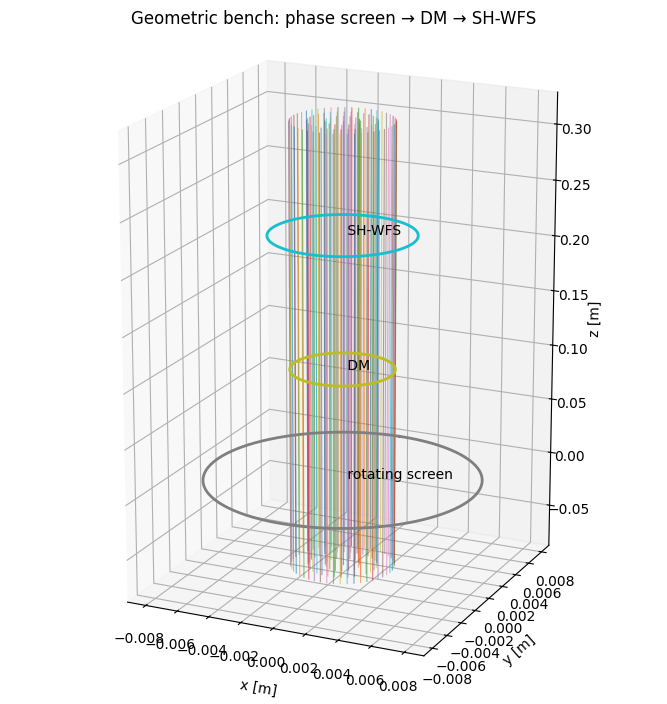

In [8]:

# Plot the geometric bench

def element_radius(elem):
    if hasattr(elem, "clear_radius"):
        return float(elem.clear_radius)
    if hasattr(elem, "aperture_radius"):
        return float(elem.aperture_radius)
    if hasattr(elem, "lenslet_pitch_m") and hasattr(elem, "n_lenslets"):
        ny, nx = elem.n_lenslets
        return 0.5 * max(nx, ny) * elem.lenslet_pitch_m
    return 1e-3


def plot_bench_3d(bench, beams, t=0.0):
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    for beam_i in beams:
        paths, _ = bench.trace_beam(beam_i, s_end=0.10, t=t)
        for path in paths:
            ax.plot(path[:, 0], path[:, 1], path[:, 2], lw=0.8, alpha=0.6)

    for elem in bench.elements:
        e1, e2 = elem.plane_basis()
        R = element_radius(elem)
        tt = np.linspace(0, 2*np.pi, 200)
        ring = elem.point[None, :] + R * (
            np.cos(tt)[:, None] * e1[None, :]
            + np.sin(tt)[:, None] * e2[None, :]
        )
        ax.plot(ring[:, 0], ring[:, 1], ring[:, 2], lw=2.0)
        ax.text(elem.point[0], elem.point[1], elem.point[2], " " + elem.label)

    ax.set_title("Geometric bench: phase screen → DM → SH-WFS")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")
    ax.set_box_aspect([1, 1, 1.5])
    try:
        ax.view_init(elev=18, azim=-65)
    except Exception:
        pass
    plt.tight_layout()
    plt.show()

plot_bench_3d(bench, [beam], t=t_demo)



## Sample wavefronts at intermediate states

We now use the ray-trace/OPD part to sample complex pupil fields:

- `screen only`: rotating phase screen OPD only,
- `screen + DM`: screen plus DM correction,
- `SH plane`: same corrected field handed off to the SH lenslet array.

For this simple collimated example, the SH plane is a handoff plane for wave optics. The SH element itself does not add additional OPD to the pupil field; it defines the lenslet geometry for the next step.


In [9]:

# Sample wavefronts for different prefixes of the bench

wf_screen, samp_screen = sample_wf(
    beam,
    elements=[screen],
    label="after rotating screen",
    t=t_demo,
)

wf_dm, samp_dm = sample_wf(
    beam,
    elements=[screen, dm],
    label="after screen + DM",
    t=t_demo,
)

# The SH object is not an OPD-producing element here. It defines lenslet
# geometry for the next cell, so the SH-plane wavefront is the field after
# screen + DM sampled on the same pupil grid.
wf_sh, samp_sh = sample_wf(
    beam,
    elements=[screen, dm],
    label="at SH plane",
    t=t_demo,
)

print("Power after screen:", wavefront_power(wf_screen))
print("Power after DM:    ", wavefront_power(wf_dm))
print("Power at SH plane: ", wavefront_power(wf_sh))
print("wf_screen:", type(wf_screen), wf_screen.shape, wf_screen.dx)
print("sample keys:", sorted(samp_screen.keys()))


Power after screen: 1.2216928962239155e-05
Power after DM:     1.2216928962239155e-05
Power at SH plane:  1.2216928962239155e-05
wf_screen: <class 'optics_simulator.wavefront.Wavefront2D'> (192, 192) 3.1413612565445084e-05
sample keys: ['amplitude', 'dx', 'mask', 'opd_map_m', 'phase_map_rad', 'xx', 'yy']


In [ ]:
dm

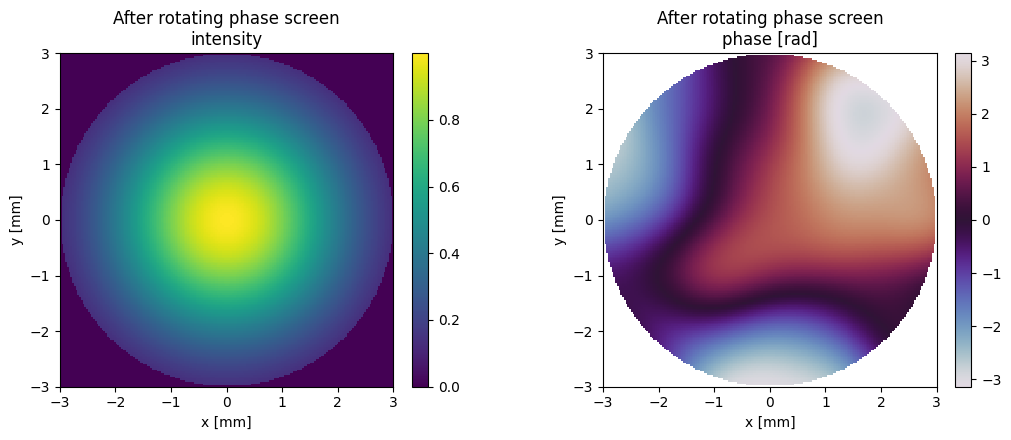

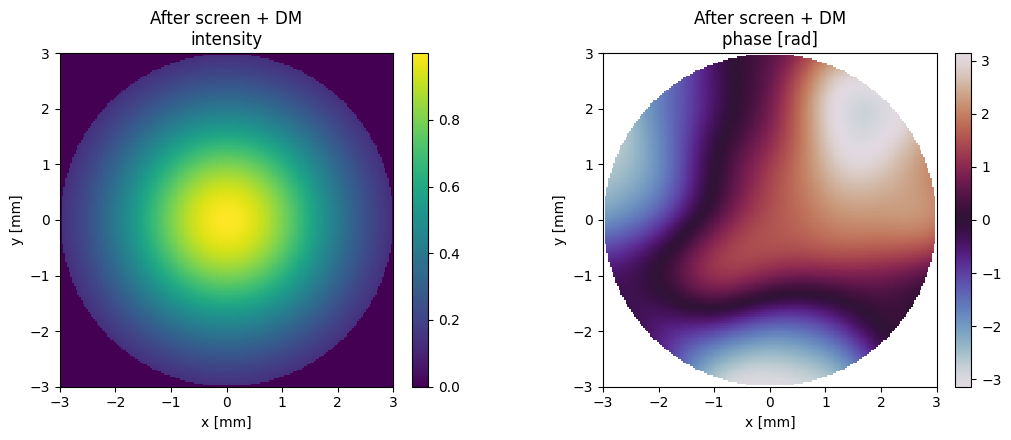

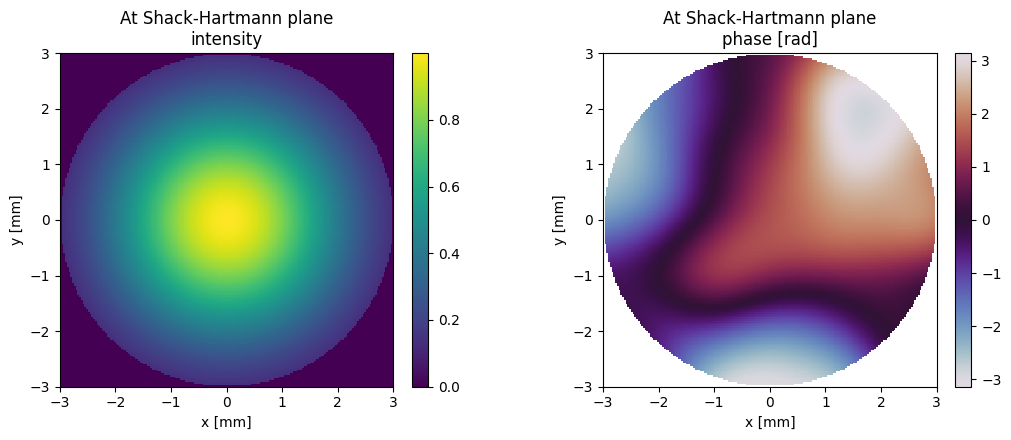

In [10]:

# Display intensity and phase maps

plot_wavefront_maps(wf_screen, "After rotating phase screen")
plot_wavefront_maps(wf_dm, "After screen + DM")
plot_wavefront_maps(wf_sh, "At Shack-Hartmann plane")


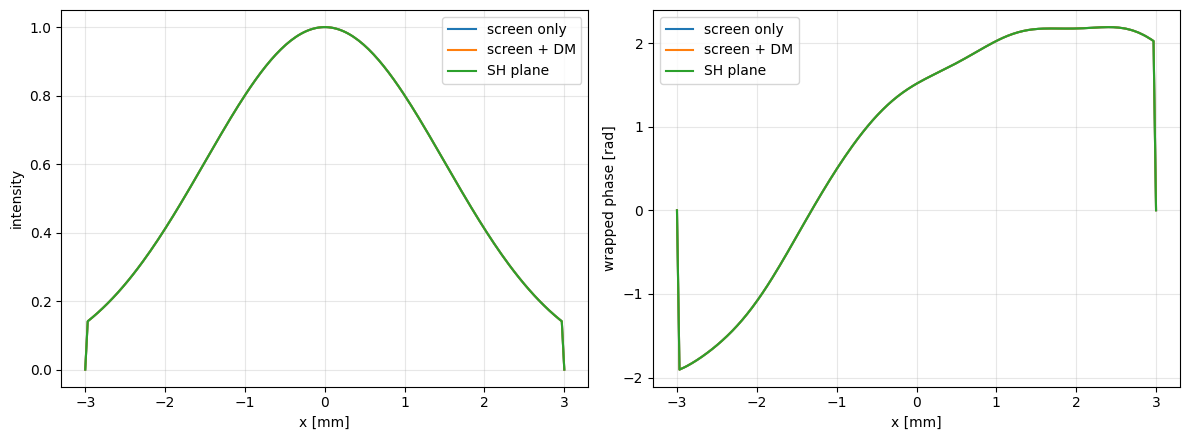

In [11]:

# Cross sections through the beam

plot_centre_cross_sections(
    [wf_screen, wf_dm, wf_sh],
    ["screen only", "screen + DM", "SH plane"],
)



## Shack–Hartmann spot simulation

This is the wave-optics handoff:

1. Take the complex `Wavefront2D` at the SH plane.
2. For each lenslet, apply the lenslet aperture mask.
3. Use the existing Fresnel/lens focal-plane function to produce a spot.
4. Place each spot into its detector cell.

This keeps the lenslet bookkeeping in `ShackHartmannWFS3D`, but uses `fresnel.lens_focal_plane_field()` for the spot formation.


In [13]:

# SH spot simulation helpers
def local_centroid(image, threshold_fraction=0.0):
    """
    Flux-weighted centroid of a 2D spot image.

    Parameters
    ----------
    image : ndarray
        2D spot image.
    threshold_fraction : float
        Optional threshold as a fraction of the peak. Pixels below this
        threshold are ignored. Use 0.0 to use all non-negative finite pixels.

    Returns
    -------
    x_centroid, y_centroid : float
        Centroid coordinates in local pixel coordinates of ``image``.
    """
    img = np.asarray(image, dtype=float)

    valid = np.isfinite(img)
    img_work = np.where(valid, img, 0.0)

    if threshold_fraction > 0:
        peak = np.nanmax(img_work)
        if peak > 0:
            img_work = np.where(img_work >= threshold_fraction * peak, img_work, 0.0)

    # Avoid negative numerical noise contributing to centroid.
    img_work = np.maximum(img_work, 0.0)

    total = np.sum(img_work)

    if not np.isfinite(total) or total <= 0:
        ny, nx = img.shape
        return 0.5 * (nx - 1), 0.5 * (ny - 1)

    yy, xx = np.indices(img.shape)

    x_centroid = np.sum(xx * img_work) / total
    y_centroid = np.sum(yy * img_work) / total

    return float(x_centroid), float(y_centroid)


def pad_center(arr, out_n):
    """
    Pad/crop a square 2D array to out_n x out_n around its centre.
    """
    arr = np.asarray(arr)
    ny, nx = arr.shape
    if ny != nx:
        n = max(ny, nx)
        tmp = np.zeros((n, n), dtype=arr.dtype)
        ys = (n - ny)//2
        xs = (n - nx)//2
        tmp[ys:ys+ny, xs:xs+nx] = arr
        arr = tmp
        ny = nx = n

    if out_n == ny:
        return arr

    if out_n > ny:
        pad = out_n - ny
        before = pad // 2
        after = pad - before
        return np.pad(arr, ((before, after), (before, after)), mode="constant")

    start = (ny - out_n)//2
    return arr[start:start+out_n, start:start+out_n]


def crop_center(arr, out_n):
    arr = np.asarray(arr)
    ny, nx = arr.shape
    cy = ny // 2
    cx = nx // 2
    h = out_n // 2
    if out_n % 2 == 0:
        return arr[cy-h:cy+h, cx-h:cx+h]
    return arr[cy-h:cy+h+1, cx-h:cx+h+1]


def bbox_from_mask(mask, margin=2):
    rows = np.where(np.any(mask, axis=1))[0]
    cols = np.where(np.any(mask, axis=0))[0]

    if rows.size == 0 or cols.size == 0:
        return None

    ys = max(0, rows[0] - margin)
    ye = min(mask.shape[0], rows[-1] + margin + 1)
    xs = max(0, cols[0] - margin)
    xe = min(mask.shape[1], cols[-1] + margin + 1)

    return ys, ye, xs, xe


def simulate_shwfs_detector(
    wf,
    sh,
    spot_pad=128,
    cell_pixels=None,
    lenslet_margin_pix=2,
    normalize=False,
):
    """
    Simulate a simple SH-WFS detector image from a Wavefront2D.

    The detector cells are defined by sh.detector_cell_bounds(). Each lenslet
    spot is generated by applying the lenslet mask and calling
    fresnel.lens_focal_plane_field().

    This is a minimal visual model:
    - no detector noise,
    - no finite pixel convolution,
    - no calibration of absolute focal-plane pixel pitch to detector pitch.
    """
    if cell_pixels is None:
        cell_pixels = sh.pixels_per_lenslet

    det = np.zeros(sh.detector_shape, dtype=float)
    spot_info = {}

    ny_lens, nx_lens = sh.n_lenslets

    for iy in range(ny_lens):
        for ix in range(nx_lens):
            if not sh.valid_lenslet_mask[iy, ix]:
                continue

            lens_mask = sh.lenslet_mask_for_grid(wf.x, wf.y, (iy, ix))
            lens_mask &= wf.amplitude > 0

            if np.count_nonzero(lens_mask) < 4:
                continue

            bbox = bbox_from_mask(lens_mask, margin=lenslet_margin_pix)
            if bbox is None:
                continue

            ys, ye, xs, xe = bbox
            field_sub = np.where(lens_mask[ys:ye, xs:xe], wf.field[ys:ye, xs:xe], 0.0)

            field_pad = pad_center(field_sub, spot_pad)

            spot_field, dx_foc, dy_foc = fresnel.lens_focal_plane_field(
                field_pad,
                wavelength=wf.wavelength,
                dx=wf.dx,
                dy=wf.dy,
                focal_length=sh.focal_length_m,
                include_global_phase=False,
            )

            spot = np.abs(spot_field) ** 2
            cell = crop_center(spot, cell_pixels)

            xs_det, xe_det, ys_det, ye_det = sh.detector_cell_bounds((iy, ix))

            cell = pad_center(cell, cell_pixels)

            det[ys_det:ye_det, xs_det:xe_det] += cell

            xp, yp = local_centroid(cell)
            spot_info[(iy, ix)] = {
                "flux": float(np.sum(cell)),
                "x_centroid_cell": xp,
                "y_centroid_cell": yp,
                "dx_focal_m": dx_foc,
                "dy_focal_m": dy_foc,
            }

    if normalize and np.nanmax(det) > 0:
        det = det / np.nanmax(det)

    return det, spot_info


det_screen, info_screen = simulate_shwfs_detector(
    wf_screen,
    sh,
    spot_pad=sh_fft_pad,
    cell_pixels=sh_pixels_per_lenslet,
    normalize=False,
)

det_dm, info_dm = simulate_shwfs_detector(
    wf_dm,
    sh,
    spot_pad=sh_fft_pad,
    cell_pixels=sh_pixels_per_lenslet,
    normalize=False,
)

print("Detector shape:", det_dm.shape)
print("Active spots screen-only:", len(info_screen))
print("Active spots screen+DM:", len(info_dm))
print("Total SH flux screen-only:", np.sum(det_screen))
print("Total SH flux screen+DM:", np.sum(det_dm))


Detector shape: (256, 256)
Active spots screen-only: 60
Active spots screen+DM: 60
Total SH flux screen-only: 610458.9405499052
Total SH flux screen+DM: 610458.9405499052


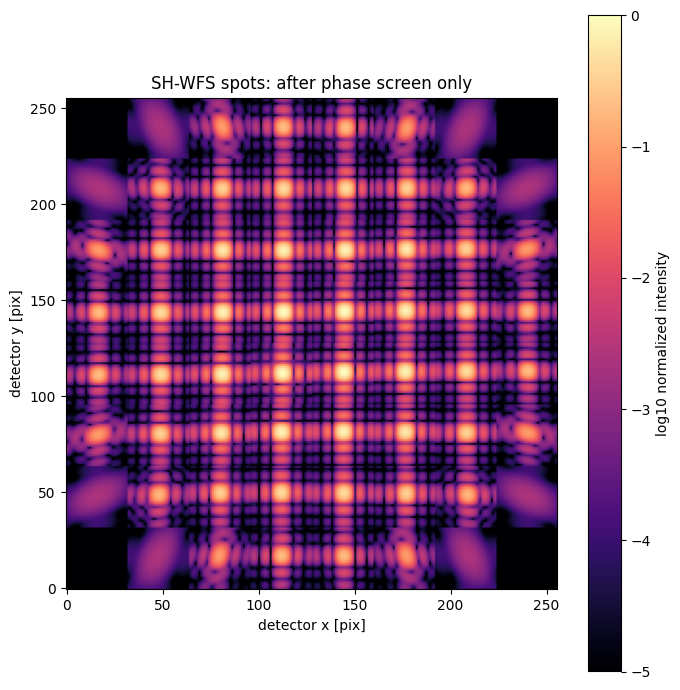

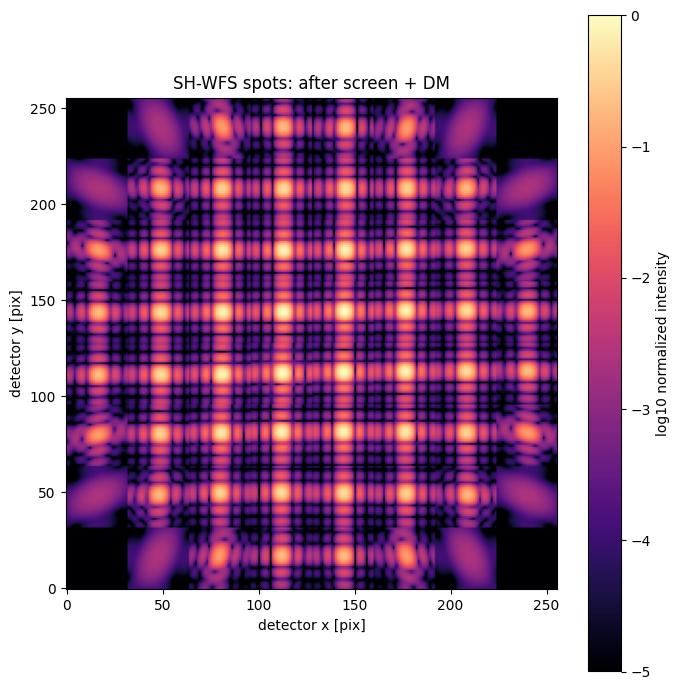

In [14]:

# Plot SH-WFS detector images

def show_detector_image(det, title, log=True):
    img = np.asarray(det, dtype=float)
    if log:
        if np.nanmax(img) > 0:
            show = np.log10(np.maximum(img / np.nanmax(img), 1e-5))
            vmin, vmax = -5, 0
        else:
            show = img
            vmin = vmax = None
    else:
        show = img
        vmin = 0
        vmax = np.nanpercentile(img, 99.5) if np.nanmax(img) > 0 else 1

    plt.figure(figsize=(7, 7))
    plt.imshow(show, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xlabel("detector x [pix]")
    plt.ylabel("detector y [pix]")
    plt.colorbar(label="log10 normalized intensity" if log else "intensity")
    plt.tight_layout()
    plt.show()


show_detector_image(det_screen, "SH-WFS spots: after phase screen only", log=True)
show_detector_image(det_dm, "SH-WFS spots: after screen + DM", log=True)


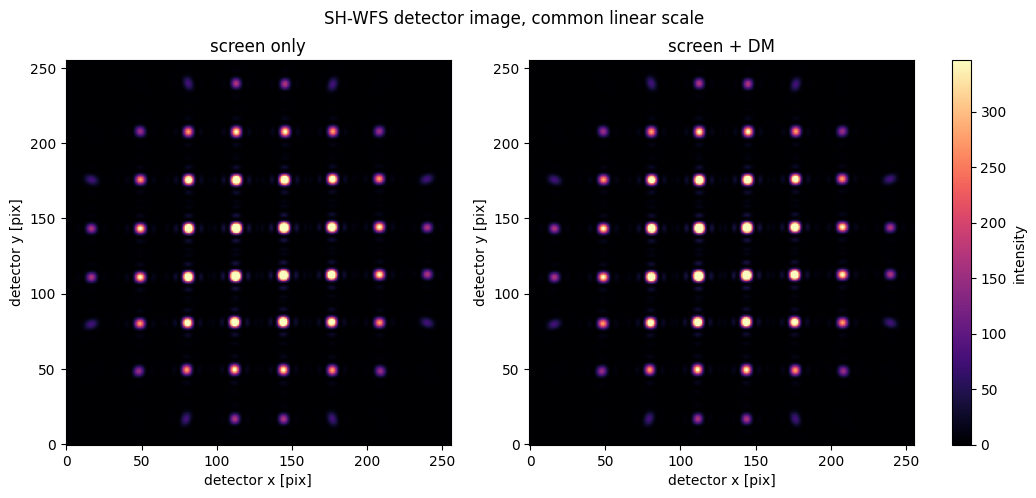

In [15]:

# Side-by-side linear display to make spot sharpening/flux differences easier to see

vmax = max(np.nanpercentile(det_screen, 99.5), np.nanpercentile(det_dm, 99.5))
if not np.isfinite(vmax) or vmax <= 0:
    vmax = 1.0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(det_screen, origin="lower", cmap="magma", vmin=0, vmax=vmax)
axes[0].set_title("screen only")
axes[0].set_xlabel("detector x [pix]")
axes[0].set_ylabel("detector y [pix]")

im1 = axes[1].imshow(det_dm, origin="lower", cmap="magma", vmin=0, vmax=vmax)
axes[1].set_title("screen + DM")
axes[1].set_xlabel("detector x [pix]")
axes[1].set_ylabel("detector y [pix]")

plt.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04, label="intensity")
plt.suptitle("SH-WFS detector image, common linear scale")
plt.show()



## Notes and next steps

This notebook is intentionally simple. The SH-WFS image is a visual wave-optics sanity check, not yet a complete detector model.

Natural next steps:

1. Add detector pixel pitch calibration so the focal-plane sampling maps explicitly to physical detector pixels.
2. Add noise, background, saturation, and centroiding windows.
3. Compare measured spot centroids against known wavefront slopes.
4. Build an interaction matrix by poking DM actuators and measuring SH slopes.
5. Use the SH slopes to close the loop against the rotating phase screen.
